Cell 1 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/fault_dataset_balanced1920_sequence_features.csv')
print(df.shape)
print(df['fault_type'].value_counts())

(1920, 168)
fault_type
Normal    320
LG        320
LL        320
LLG       320
LLLG      320
HIF       320
Name: count, dtype: int64


Cell 2 — Class distribution (Before training any ML model, let's check whether the dataset is balanced.)

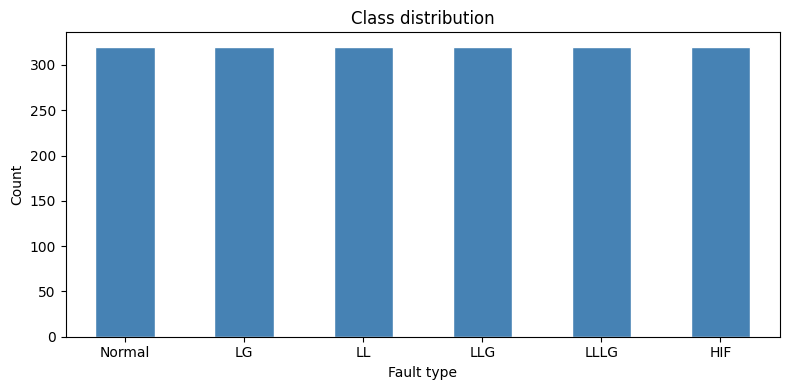

In [4]:
fig, ax = plt.subplots(figsize=(8,4))
df['fault_type'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Class distribution')
ax.set_xlabel('Fault type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

Cell 3 — Voltage magnitude per fault type (This graph checks: "Do different fault types actually create different voltage patterns?")

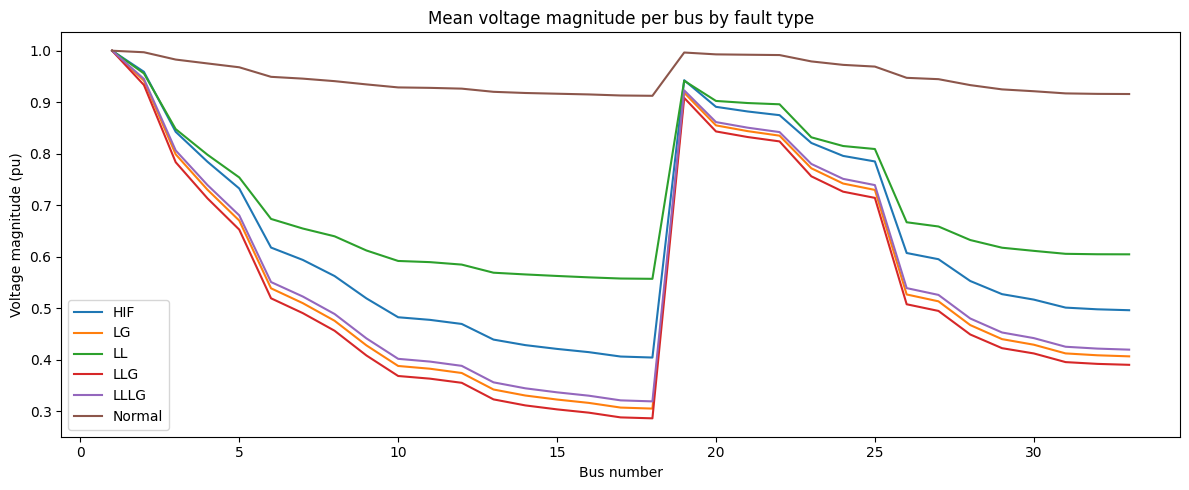

In [5]:
vmag_cols = [f'V_bus{i}' for i in range(1, 34)]
vmag_mean = df.groupby('fault_type')[vmag_cols].mean()
fig, ax = plt.subplots(figsize=(12, 5))
for ft in vmag_mean.index:
    ax.plot(range(1, 34), vmag_mean.loc[ft], label=ft, linewidth=1.5)
ax.set_title('Mean voltage magnitude per bus by fault type')
ax.set_xlabel('Bus number')
ax.set_ylabel('Voltage magnitude (pu)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/vmag_per_fault_type.png', dpi=150)
plt.show()    

Cell 4 — Sequence components
 
The purpose is:

"Do different fault types create different sequence-component patterns?"

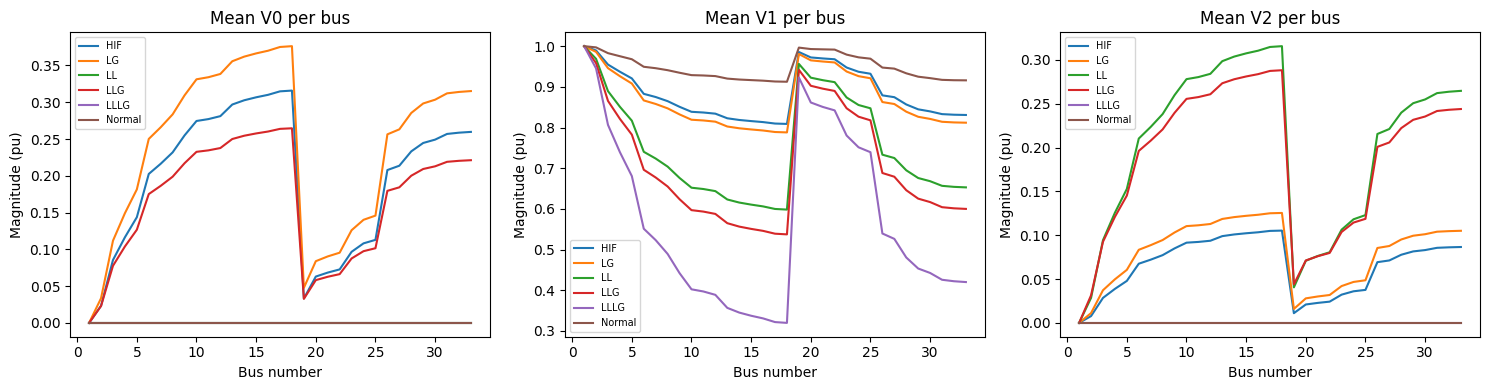

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, seq in zip(axes, ['V0', 'V1', 'V2']):
    cols = [f'{seq}_bus{i}' for i in range(1, 34)]
    mean = df.groupby('fault_type')[cols].mean()
    for ft in mean.index:
        ax.plot(range(1, 34), mean.loc[ft], label=ft, linewidth=1.5)
    ax.set_title(f'Mean {seq} per bus')
    ax.set_xlabel('Bus number')
    ax.set_ylabel('Magnitude (pu)')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('../results/sequence_components.png', dpi=150)
plt.show()

Cell 5 — Correlation heatmap (V_bus only)

This cell asks:

Which bus voltages behave similarly?


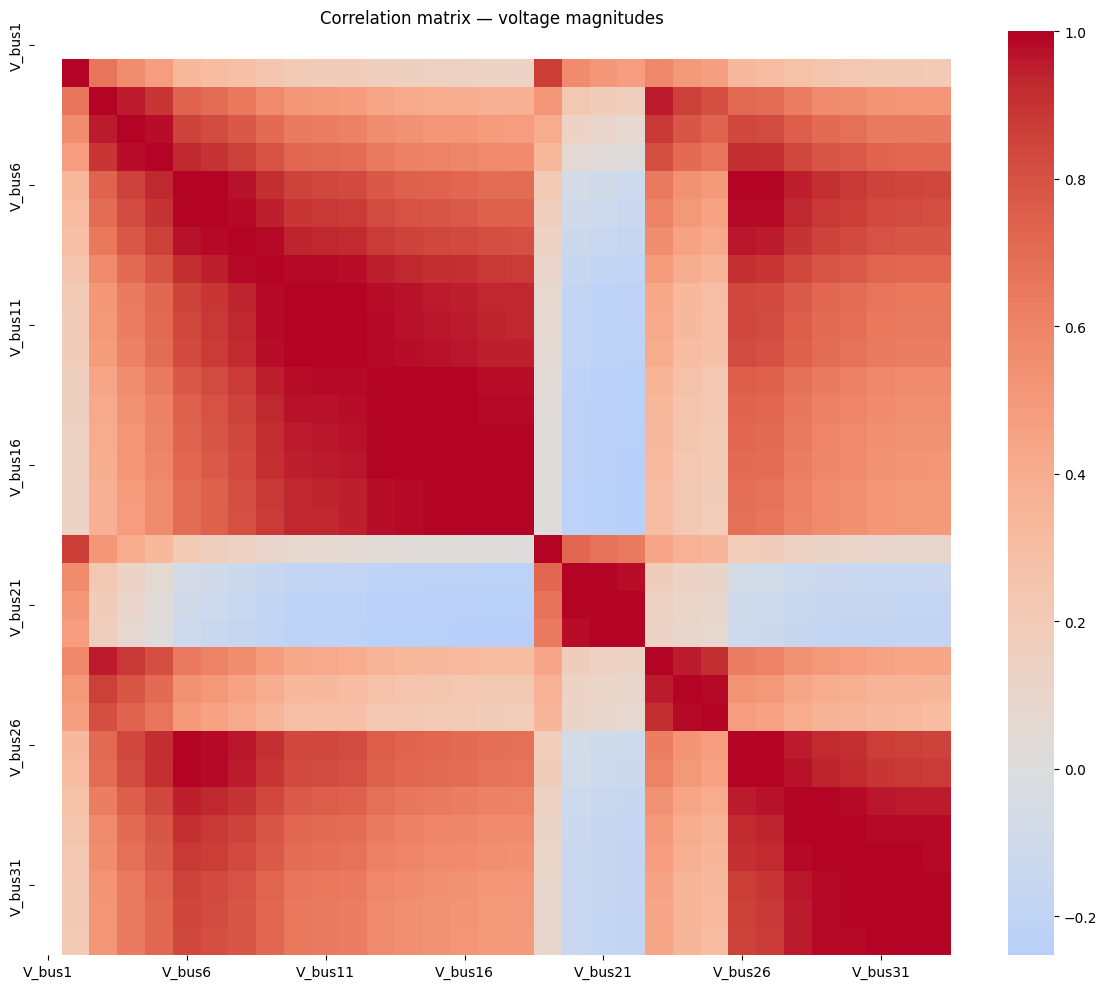

In [7]:
vmag_df = df[[f'V_bus{i}' for i in range(1, 34)]]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(vmag_df.corr(), ax=ax, cmap='coolwarm', center=0,
            xticklabels=5, yticklabels=5, linewidths=0)
ax.set_title('Correlation matrix — voltage magnitudes')
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150)
plt.show()

Cell 6 — Feature matrix and labels (correct)\

This cell is:

Prepare the data for ML models

In [8]:
feature_cols = (
    [f'V_bus{i}' for i in range(1, 34)] +
    [f'Angle_bus{i}' for i in range(1, 34)] +
    [f'V0_bus{i}' for i in range(1, 34)] +
    [f'V1_bus{i}' for i in range(1, 34)] +
    [f'V2_bus{i}' for i in range(1, 34)]
)

# Task A: Fault type classification — all 1920 rows
X_type = df[feature_cols]
y_type = df['fault_type']

# Task B: Fault location prediction — fault rows only, no Normal
df_faults = df[df['fault_type'] != 'Normal']
X_bus = df_faults[feature_cols]
y_bus = df_faults['fault_bus']

print(f'Task A — X shape: {X_type.shape}, classes: {y_type.unique()}')
print(f'Task B — X shape: {X_bus.shape}, buses: {sorted(y_bus.unique())}')

Task A — X shape: (1920, 165), classes: <StringArray>
['Normal', 'LG', 'LL', 'LLG', 'LLLG', 'HIF']
Length: 6, dtype: str
Task B — X shape: (1600, 165), buses: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33)]
